In [ ]:
%pip install pandas
%pip install scipy
%pip install seaborn
%pip install statsmodels


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import itertools
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt


In [6]:
def co_occurence_calculator(matrix, low_threshold, high_threshold, label):
    matrix = matrix.copy()
    matrix['Class'] = matrix['Class'].str.split('/') # / classes into a list 
    matrix = matrix.explode('Class').reset_index(drop=True) # lists split to make separate rows
    n_point = matrix[(matrix['Subtype'] != 'POINT') & (matrix['Subtype'] != 'POINT_DISRUPT')]
    n_point = n_point[(n_point['Class'] != 'EFFLUX')]

    #Shows what genes are present in each accession in a table, binary
    n_point_matrix = n_point.drop_duplicates(['accession', 'Class']).dropna(subset=['Class']).assign(present=1).pivot(index='accession', columns='Class', values='present').fillna(0)

    sns.heatmap(n_point_matrix, cmap='Blues', cbar=False, linewidths=0.5, linecolor='grey')
    plt.title(f'Resistance class presence/absence ({label})')
    #plt.savefig(f'plots/presence_absence_{label}.png', dpi=300, bbox_inches='tight')
    plt.show()

    prevalence = n_point_matrix.sum() 
    keep = prevalence[(prevalence >= low_threshold) & (prevalence <= high_threshold)].index #Too high or low don't carry and info about coocurrence
    co_occur_matrix = n_point_matrix[keep]

    combinations = itertools.combinations(co_occur_matrix, 2) #creates list of lists of every 2 combination (not including axa, or b x a if a x b is done)
    f_results = []
    for option in combinations:
        table = pd.crosstab(co_occur_matrix[option[0]], co_occur_matrix[option[1]]) #Makes 2x2 for each pair of classes
        table = table.reindex(index=[0,1], columns=[0,1], fill_value=0) #Make sure table 2x2, fill empty cells
        odds_ratio, p_value = stats.fisher_exact(table)
        f_results.append({
            'Class A': option[0],
            'Class B': option[1],
            'odds_ratio': odds_ratio,
            'p_value': p_value
        })

    f_df=pd.DataFrame(f_results)

    significant, p_corrected, _, _ = multipletests(f_df['p_value'], method='fdr_bh') # corrects for multiple p tests
    f_df['significant'] = significant
    f_df['corrected_p_values'] = p_corrected 
    f_df['score'] = -np.log10(f_df['p_value']) * np.where(f_df['odds_ratio'] > 1, 1, -1) #shows direction and strength

    final_co = pd.DataFrame(0.0, index=co_occur_matrix.columns, columns=co_occur_matrix.columns)

    for _, row in f_df.iterrows():
        a = row['Class A']
        b = row['Class B']
        score = row['score']
        final_co.loc[a, b] = score 
        final_co.loc[b, a] = score

    sns.heatmap(final_co, cmap='RdBu_r', center=0, annot=True, fmt='.1f',
                linewidths=0.5, square=True, cbar_kws={'label': 'signed -log10(p)'})
    plt.title(f'Resistance class co-occurrence ({label})')
    plt.figtext(0.5, -0.02,
                'Colour shows raw association strength; only pairs surviving multiple-comparison correction are claimed as significant.',
                ha='center', fontsize=8, wrap=True)
    plt.tight_layout()
    #plt.savefig(f'plots/cooccurrence_{label}.png', dpi=300, bbox_inches='tight')
    plt.show()

    return f_df

In [7]:
amr_folder = Path("../results/amr")

dfs = []
for tsv in amr_folder.glob("*.tsv"):
    df = pd.read_csv(tsv, sep="\t")
    df["accession"] = tsv.stem
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)
#combined = combined[~combined['accession'].isin(['DRR898376', 'DRR898377'])] #Remove fragmented accessions

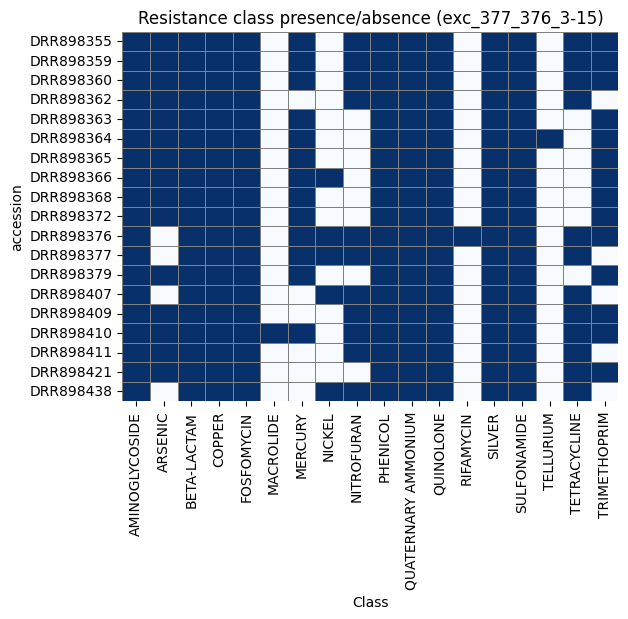

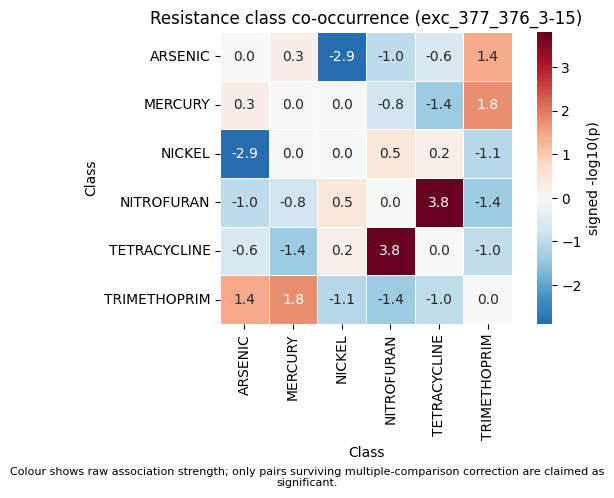

,Class A,Class B,odds_ratio,p_value,significant,corrected_p_values,score
0,ARSENIC,MERCURY,2.750000,0.557276,False,0.643010,0.253930
1,ARSENIC,NICKEL,0.000000,0.001290,True,0.009675,-2.889414
2,ARSENIC,NITROFURAN,0.000000,0.103199,False,0.176729,-0.986324
3,ARSENIC,TETRACYCLINE,0.000000,0.245098,False,0.334225,-0.610660
4,ARSENIC,TRIMETHOPRIM,19.500000,0.037410,False,0.111369,1.427016
5,MERCURY,NICKEL,0.600000,1.000000,False,1.000000,0.000000
6,MERCURY,NITROFURAN,0.171429,0.176987,False,0.265480,-0.752060
7,MERCURY,TETRACYCLINE,0.000000,0.043602,False,0.111369,-1.360497
8,MERCURY,TRIMETHOPRIM,24.000000,0.017286,False,0.086429,1.762309
9,NICKEL,NITROFURAN,4.000000,0.337805,False,0.422257,0.471334


In [8]:
co_occurence_calculator(combined, 3, 15, 'exc_377_376_3-15')